In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_excel("employee_dataset1.xlsx")

In [5]:
df.head(10)

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
1,2,Timothy Sanchez,25,Other,Sales,4249,2020-11-09,2.0,11,Inactive,Los Angeles,Evening
2,3,Chad Nichols,57,Other,Sales,3058,2019-02-12,NaN,1,Inactive,New York,Morning
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
4,5,Amber Harris,35,Other,IT,4317,2020-02-15,5.0,16,Inactive,New York,Evening
5,6,Ashley Howe,29,Female,HR,2591,2016-06-24,1.0,6,Active,Chicago,Evening
6,7,David Olson,39,Female,Sales,6826,2023-05-11,NaN,4,Active,New York,Night
7,8,Amanda Baker,52,Other,HR,6285,2015-04-01,NaN,8,Inactive,Chicago,Evening
8,9,Jeremy Wright,63,Female,Sales,9862,2024-02-07,NaN,3,Inactive,New York,Night
9,10,Brian Faulkner,30,Male,IT,8202,2018-05-26,1.0,9,Active,Los Angeles,Morning


In [191]:
df.shape

(1000, 12)

In [193]:
print(df.isnull().sum)

<bound method DataFrame.sum of         ID   Name    Age  Gender  Department  Salary  Joining Date  \
0    False  False  False   False       False   False         False   
1    False  False  False   False       False   False         False   
2    False  False  False   False       False   False         False   
3    False  False  False   False       False   False         False   
4    False  False  False   False       False   False         False   
..     ...    ...    ...     ...         ...     ...           ...   
995  False  False  False   False       False   False         False   
996  False  False  False   False       False   False         False   
997  False  False  False   False       False   False         False   
998  False  False  False   False       False   False         False   
999  False  False  False   False       False   False         False   

     Performance Score  Experience  Status  Location  Session  
0                False       False   False     False    False  


In [194]:
df.describe()

,ID,Age,Salary,Joining Date,Performance Score,Experience
count,1000.000000,1000.000000,1000.000000,1000,502.000000,1000.000000
mean,500.500000,40.782000,5917.374000,2020-01-04 21:23:02.400000,2.910359,10.120000
min,1.000000,18.000000,2015.000000,2014-12-11 00:00:00,1.000000,1.000000
25%,250.750000,28.000000,3829.750000,2017-08-22 06:00:00,2.000000,5.000000
50%,500.500000,40.000000,5889.000000,2020-03-01 12:00:00,3.000000,10.000000
75%,750.250000,52.000000,7903.250000,2022-05-30 00:00:00,4.000000,15.000000
max,1000.000000,65.000000,9993.000000,2024-12-07 00:00:00,5.000000,20.000000
std,288.819436,14.124871,2299.418003,NaN,1.424736,5.713689


In [195]:
df.info

<bound method DataFrame.info of        ID                Name  Age  Gender Department  Salary Joining Date  \
0       1        Cory Escobar   48  Female         HR    5641   2015-05-03   
1       2     Timothy Sanchez   25   Other      Sales    4249   2020-11-09   
2       3        Chad Nichols   57   Other      Sales    3058   2019-02-12   
3       4  Christine Williams   58  Female         IT    5895   2017-09-08   
4       5        Amber Harris   35   Other         IT    4317   2020-02-15   
..    ...                 ...  ...     ...        ...     ...          ...   
995   996       Pamela Reeves   49  Female      Sales    7652   2024-06-23   
996   997        Todd Johnson   29  Female      Sales    6754   2018-07-20   
997   998     Michael Sanchez   18    Male      Sales    5278   2023-07-05   
998   999       Ashley Taylor   51  Female         IT    5437   2022-02-18   
999  1000         Shawn Scott   45    Male         IT    7364   2022-07-31   

     Performance Score  Experie

In [196]:
print("duplicates before:",df.duplicated().sum())

duplicates before: 0


In [198]:
df.dtypes

ID                            int64
Name                         object
Age                           int64
Gender                       object
Department                   object
Salary                        int64
Joining Date         datetime64[ns]
Performance Score           float64
Experience                    int64
Status                       object
Location                     object
Session                      object
dtype: object

In [199]:
df["Salary"] = pd.to_numeric(df["Salary"])
df["Performance Score"] = pd.to_numeric(df["Performance Score"])

In [204]:
print("Final Shape :",df.shape) 
print("Missing Values:\n")
print(df.isnull().sum())

Final Shape : (1000, 12)
Missing Values:

ID                     0
Name                   0
Age                    0
Gender                 0
Department             0
Salary                 0
Joining Date           0
Performance Score    498
Experience             0
Status                 0
Location               0
Session                0
dtype: int64


In [20]:
dept_Performance = df.groupby("Department")["Performance Score"].mean()
print(dept_Performance)

Department
HR       2.856287
IT       2.975758
Sales    2.900000
Name: Performance Score, dtype: float64


In [22]:
top10 = df.sort_values(
    by="Performance Score",
    ascending=False
).head(10)

print(top10)

      ID               Name  Age  Gender Department  Salary Joining Date  \
421  422        Dylan Dixon   19  Female         IT    8798   2015-06-07   
155  156    Raymond Johnson   56  Female         IT    5982   2016-12-03   
836  837        Bryan Walsh   42  Female         IT    7551   2018-04-11   
732  733          Jay Evans   21    Male         HR    8147   2022-03-29   
509  510  Christopher Black   62  Female         HR    3278   2021-08-29   
510  511      Charles Smith   24  Female         IT    5716   2019-12-13   
576  577       Chad Kennedy   49    Male      Sales    7111   2022-03-15   
832  833        Susan Davis   54  Female      Sales    4232   2015-07-03   
313  314      Kenneth Brown   33    Male      Sales    4391   2020-05-03   
466  467    Janet Carpenter   65   Other      Sales    7570   2024-08-04   

     Performance Score  Experience    Status     Location  Session  
421                5.0          15    Active  Los Angeles  Evening  
155                5.0   

In [24]:
print(df["Performance Score"].value_counts().sort_index())

Performance Score
1.0    103
2.0    125
3.0     87
4.0     88
5.0     99
Name: count, dtype: int64


In [26]:
correlation = df["Experience"].corr(df["Performance Score"])
print("correlation:",correlation)

correlation: -0.011526222212406737


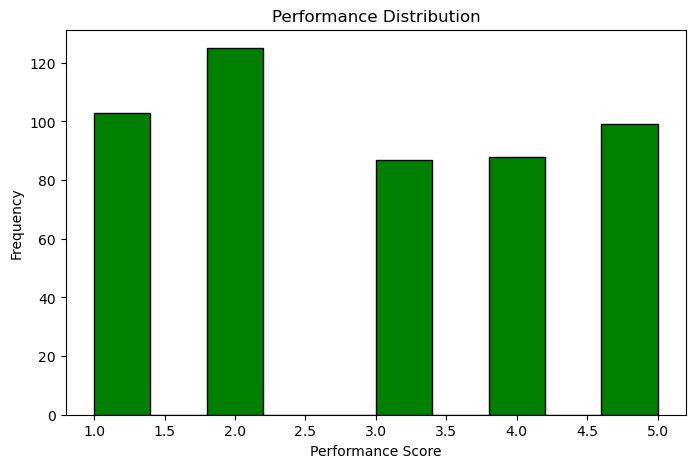

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Performance Score"],
    bins=10,
    color='green',
    edgecolor='black'
)

plt.title("Performance Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Frequency")

plt.show()

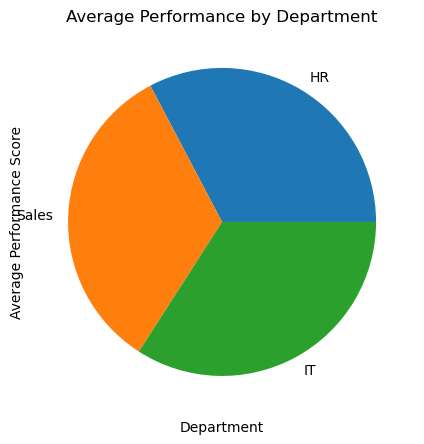

In [30]:
plt.figure(figsize=(10,5))

dept_Performance.sort_values().plot(
    kind='pie',
    color='orange'
)

plt.title("Average Performance by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Score")

plt.show()

In [32]:
df[df["Age"]>25]


,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
2,3,Chad Nichols,57,Other,Sales,3058,2019-02-12,NaN,1,Inactive,New York,Morning
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
4,5,Amber Harris,35,Other,IT,4317,2020-02-15,5.0,16,Inactive,New York,Evening
5,6,Ashley Howe,29,Female,HR,2591,2016-06-24,1.0,6,Active,Chicago,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...
993,994,Brandon Bruce,31,Female,HR,3371,2018-09-25,5.0,12,Inactive,Chicago,Night
995,996,Pamela Reeves,49,Female,Sales,7652,2024-06-23,4.0,3,Active,Los Angeles,Evening
996,997,Todd Johnson,29,Female,Sales,6754,2018-07-20,NaN,12,Inactive,New York,Morning
998,999,Ashley Taylor,51,Female,IT,5437,2022-02-18,4.0,9,Inactive,Los Angeles,Evening


In [38]:
df[df["Salary"]>5000]

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
6,7,David Olson,39,Female,Sales,6826,2023-05-11,NaN,4,Active,New York,Night
7,8,Amanda Baker,52,Other,HR,6285,2015-04-01,NaN,8,Inactive,Chicago,Evening
8,9,Jeremy Wright,63,Female,Sales,9862,2024-02-07,NaN,3,Inactive,New York,Night
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Pamela Reeves,49,Female,Sales,7652,2024-06-23,4.0,3,Active,Los Angeles,Evening
996,997,Todd Johnson,29,Female,Sales,6754,2018-07-20,NaN,12,Inactive,New York,Morning
997,998,Michael Sanchez,18,Male,Sales,5278,2023-07-05,5.0,3,Active,New York,Morning
998,999,Ashley Taylor,51,Female,IT,5437,2022-02-18,4.0,9,Inactive,Los Angeles,Evening


In [40]:
len(df)

1000

In [48]:
df["Salary"].mean()

5917.374

In [50]:
df["Salary"].max()

9993

In [52]:
df.sort_values("Salary")

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
906,907,Christina Carlson,42,Female,Sales,2015,2020-05-08,1.0,14,Inactive,Chicago,Evening
473,474,David Potter,56,Male,IT,2016,2020-07-13,NaN,18,Active,New York,Morning
76,77,Victor Nelson,47,Female,Sales,2025,2015-05-14,1.0,5,Active,New York,Night
882,883,Jaclyn Collins,47,Male,IT,2029,2019-12-05,NaN,17,Active,Los Angeles,Morning
426,427,Patricia Scott,52,Male,HR,2041,2022-11-22,1.0,8,Inactive,Chicago,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...
937,938,Gary Mitchell,52,Female,Sales,9963,2016-09-22,5.0,20,Inactive,Los Angeles,Morning
127,128,Ashley Williams,65,Female,HR,9973,2020-05-03,NaN,19,Inactive,New York,Morning
989,990,Shannon Meyer,18,Other,HR,9985,2022-11-05,4.0,18,Active,Chicago,Night
531,532,Jeffrey Williamson,54,Other,IT,9988,2015-12-08,NaN,16,Inactive,Chicago,Evening


In [54]:
df.groupby("Department").size()

Department
HR       323
IT       339
Sales    338
dtype: int64

In [56]:
df[df["Status"] == "Active"]


,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
5,6,Ashley Howe,29,Female,HR,2591,2016-06-24,1.0,6,Active,Chicago,Evening
6,7,David Olson,39,Female,Sales,6826,2023-05-11,NaN,4,Active,New York,Night
9,10,Brian Faulkner,30,Male,IT,8202,2018-05-26,1.0,9,Active,Los Angeles,Morning
10,11,Nicole Bell,42,Female,Sales,5336,2015-01-28,3.0,7,Active,Los Angeles,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...
989,990,Shannon Meyer,18,Other,HR,9985,2022-11-05,4.0,18,Active,Chicago,Night
990,991,Amy Johnston,53,Female,HR,3991,2024-09-03,4.0,8,Active,Chicago,Morning
995,996,Pamela Reeves,49,Female,Sales,7652,2024-06-23,4.0,3,Active,Los Angeles,Evening
997,998,Michael Sanchez,18,Male,Sales,5278,2023-07-05,5.0,3,Active,New York,Morning


In [58]:
df[(df["Salary"]>=3000) & (df["Salary"]<=6000)]

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
1,2,Timothy Sanchez,25,Other,Sales,4249,2020-11-09,2.0,11,Inactive,Los Angeles,Evening
2,3,Chad Nichols,57,Other,Sales,3058,2019-02-12,NaN,1,Inactive,New York,Morning
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
4,5,Amber Harris,35,Other,IT,4317,2020-02-15,5.0,16,Inactive,New York,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...
992,993,Ashley Daniels,25,Other,Sales,5524,2022-11-24,NaN,8,Inactive,New York,Morning
993,994,Brandon Bruce,31,Female,HR,3371,2018-09-25,5.0,12,Inactive,Chicago,Night
994,995,Rachel Phillips,22,Male,IT,3096,2018-10-27,2.0,7,Inactive,Chicago,Evening
997,998,Michael Sanchez,18,Male,Sales,5278,2023-07-05,5.0,3,Active,New York,Morning


In [60]:
df[df["Gender"] == "Female"]

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
5,6,Ashley Howe,29,Female,HR,2591,2016-06-24,1.0,6,Active,Chicago,Evening
6,7,David Olson,39,Female,Sales,6826,2023-05-11,NaN,4,Active,New York,Night
8,9,Jeremy Wright,63,Female,Sales,9862,2024-02-07,NaN,3,Inactive,New York,Night
...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,Amy Johnston,53,Female,HR,3991,2024-09-03,4.0,8,Active,Chicago,Morning
993,994,Brandon Bruce,31,Female,HR,3371,2018-09-25,5.0,12,Inactive,Chicago,Night
995,996,Pamela Reeves,49,Female,Sales,7652,2024-06-23,4.0,3,Active,Los Angeles,Evening
996,997,Todd Johnson,29,Female,Sales,6754,2018-07-20,NaN,12,Inactive,New York,Morning


In [62]:
df[(df["Age"]>25) & (df["Salary"]>5000)]

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
6,7,David Olson,39,Female,Sales,6826,2023-05-11,NaN,4,Active,New York,Night
7,8,Amanda Baker,52,Other,HR,6285,2015-04-01,NaN,8,Inactive,Chicago,Evening
8,9,Jeremy Wright,63,Female,Sales,9862,2024-02-07,NaN,3,Inactive,New York,Night
...,...,...,...,...,...,...,...,...,...,...,...,...
988,989,Hannah Hickman,36,Female,IT,9118,2022-07-02,5.0,5,Active,New York,Night
995,996,Pamela Reeves,49,Female,Sales,7652,2024-06-23,4.0,3,Active,Los Angeles,Evening
996,997,Todd Johnson,29,Female,Sales,6754,2018-07-20,NaN,12,Inactive,New York,Morning
998,999,Ashley Taylor,51,Female,IT,5437,2022-02-18,4.0,9,Inactive,Los Angeles,Evening


In [64]:
df.groupby("Department").size()

Department
HR       323
IT       339
Sales    338
dtype: int64

In [66]:
df.groupby("Department")["Salary"].mean()

Department
HR       5982.396285
IT       5968.371681
Sales    5804.088757
Name: Salary, dtype: float64

In [68]:
df.groupby("Department")["Salary"].max()

Department
HR       9993
IT       9988
Sales    9963
Name: Salary, dtype: int64

In [74]:
df.sort_values("Salary",ascending = False)

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
811,812,Jesse Miller,52,Male,HR,9993,2020-11-27,NaN,12,Active,Chicago,Evening
531,532,Jeffrey Williamson,54,Other,IT,9988,2015-12-08,NaN,16,Inactive,Chicago,Evening
989,990,Shannon Meyer,18,Other,HR,9985,2022-11-05,4.0,18,Active,Chicago,Night
127,128,Ashley Williams,65,Female,HR,9973,2020-05-03,NaN,19,Inactive,New York,Morning
937,938,Gary Mitchell,52,Female,Sales,9963,2016-09-22,5.0,20,Inactive,Los Angeles,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...
426,427,Patricia Scott,52,Male,HR,2041,2022-11-22,1.0,8,Inactive,Chicago,Evening
882,883,Jaclyn Collins,47,Male,IT,2029,2019-12-05,NaN,17,Active,Los Angeles,Morning
76,77,Victor Nelson,47,Female,Sales,2025,2015-05-14,1.0,5,Active,New York,Night
473,474,David Potter,56,Male,IT,2016,2020-07-13,NaN,18,Active,New York,Morning
